# Deep Learning Beat Classification Experiments

Compares MLP, 1D-CNN, and LSTM on MIT-BIH 3-class (N/S/V) beat classification.

**Key methodological choices:**
- DS1/DS2 inter-patient split (no data leakage)
- Class-weighted loss for imbalanced classes
- MLP uses extracted features (34); CNN and LSTM use raw 144-sample beat waveforms
- Early stopping on validation loss
- All results directly comparable to GB baseline (macro F1 0.702)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import mlflow
import copy
import os

from ecg_monitor.pipeline import (
    FEATURE_COLS,
    DS1_RECORDS,
    DS2_RECORDS,
    DATA_DIR,
    PACED_RECORDS,
    build_df_all,
    get_train_test_split,
)

# --- MLflow config ---
MLFLOW_TRACKING_DIR = os.path.abspath(os.path.join(os.getcwd(), 'mlruns'))
mlflow.set_tracking_uri(f'file://{MLFLOW_TRACKING_DIR}')
mlflow.set_experiment('beat_classification_pytorch')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'MLflow tracking: {MLFLOW_TRACKING_DIR}')

/Users/dominicktan/projects/personal/ecg_monitor/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/28 15:25:51 INFO mlflow.tracking.fluent: Experiment with name 'beat_classification_pytorch' does not exist. Creating a new experiment.


Device: cpu
MLflow tracking: /Users/dominicktan/projects/personal/ecg_monitor/mlruns


In [2]:
# Build dataset with beat waveforms retained
df_all, pca, pw_pca = build_df_all(
    data_dir=DATA_DIR,
    paced_records=PACED_RECORDS,
    pca_fit_records=DS1_RECORDS,
    keep_waveforms=True,
    verbose=True,
)

# DS1/DS2 inter-patient split
df_train, df_test = get_train_test_split(df_all)
print(f'\nTrain: {len(df_train)} beats ({df_train["record"].nunique()} records)')
print(f'Test:  {len(df_test)} beats ({df_test["record"].nunique()} records)')
print(f'\nTrain label distribution:\n{df_train["clinical_label"].value_counts().to_string()}')
print(f'\nTest label distribution:\n{df_test["clinical_label"].value_counts().to_string()}')

Record 100: 2271 beats
Record 101: 1861 beats
Record 102: SKIPPED (paced)
Record 103: 2081 beats
Record 104: SKIPPED (paced)
Record 105: 2530 beats
Record 106: 2024 beats
Record 107: SKIPPED (paced)
Record 108: 1749 beats
Record 109: 2531 beats
Record 111: 2122 beats
Record 112: 2534 beats
Record 113: 1794 beats
Record 114: 1878 beats
Record 115: 1949 beats
Record 116: 2410 beats
Record 117: 1534 beats
Record 118: 2273 beats
Record 119: 1986 beats
Record 121: 1859 beats
Record 122: 2474 beats
Record 123: 1516 beats
Record 124: 1618 beats
Record 200: 2583 beats
Record 201: 1956 beats
Record 202: 2132 beats
Record 203: 2905 beats
Record 205: 2643 beats
Record 207: 1745 beats
Record 208: 2935 beats
Record 209: 2985 beats
Record 210: 2638 beats
Record 212: 2742 beats
Record 213: 3249 beats
Record 214: 2254 beats
Record 215: 3340 beats
Record 217: SKIPPED (paced)
Record 219: 2033 beats
Record 220: 2043 beats
Record 221: 2417 beats
Record 222: 2447 beats
Record 223: 2601 beats
Record 228: 20

In [3]:
# --- Encode labels ---
classes = sorted(df_train['clinical_label'].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
print(f'Classes: {class_to_idx}')

y_train_enc = np.array([class_to_idx[y] for y in df_train['clinical_label'].values])
y_test_enc = np.array([class_to_idx[y] for y in df_test['clinical_label'].values])

# --- Tabular features (for MLP) ---
scaler = StandardScaler()
X_train_tab = scaler.fit_transform(df_train[FEATURE_COLS].values)
X_test_tab = scaler.transform(df_test[FEATURE_COLS].values)

# --- Raw beat waveforms (for CNN / LSTM) ---
# 144 samples: 250ms pre + 150ms post R-peak at 360 Hz
X_train_wf = np.stack(df_train['beat_waveform'].values)  # already z-scored per-beat in pipeline
X_test_wf = np.stack(df_test['beat_waveform'].values)
print(f'Waveform shape: {X_train_wf.shape[1]} samples per beat')

# --- Class weights ---
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f'Class weights: {dict(zip(classes, class_weights.round(3)))}')

Classes: {'N': 0, 'S': 1, 'V': 2}
Waveform shape: 144 samples per beat
Class weights: {'N': np.float64(0.37), 'S': np.float64(18.186), 'V': np.float64(4.161)}


In [4]:
def make_loaders(X_train, X_test, y_train, y_test, batch_size=256):
    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long),
    )
    test_ds = TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long),
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader


def train_model(model, train_loader, test_loader, epochs=50, lr=1e-3, patience=7):
    """Train with early stopping on validation loss. Logs epoch metrics to MLflow."""
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    best_val_loss = float('inf')
    best_state = None
    wait = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_loss = total_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out = model(Xb)
                loss = criterion(out, yb)
                val_loss += loss.item()
        val_loss /= len(test_loader)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        mlflow.log_metrics({
            'train_loss': train_loss,
            'val_loss': val_loss,
            'lr': optimizer.param_groups[0]['lr'],
        }, step=epoch)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            marker = ' *'
        else:
            wait += 1
            marker = ''

        if (epoch + 1) % 5 == 0 or wait == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f'Epoch {epoch+1:3d}: Train={train_loss:.4f} | Val={val_loss:.4f} | LR={lr_now:.1e}{marker}')

        if wait >= patience:
            print(f'Early stopping at epoch {epoch+1} (best val loss: {best_val_loss:.4f})')
            break

    model.load_state_dict(best_state)
    mlflow.log_metric('best_val_loss', best_val_loss)
    mlflow.log_metric('epochs_trained', len(train_losses))
    return train_losses, val_losses


def evaluate_model(model, test_loader, title=''):
    """Evaluate, print classification report, and log metrics + artifacts to MLflow."""
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            out = model(Xb)
            p = torch.argmax(out, dim=1).cpu().numpy()
            preds.extend(p)
            labels.extend(yb.numpy())

    pred_labels = [idx_to_class[p] for p in preds]
    true_labels = [idx_to_class[y] for y in labels]

    macro_f1 = f1_score(true_labels, pred_labels, average='macro')
    per_class = f1_score(true_labels, pred_labels, labels=classes, average=None)
    acc = np.mean(np.array(pred_labels) == np.array(true_labels))

    print(f'\n=== {title} ===')
    report = classification_report(true_labels, pred_labels, digits=3)
    print(report)
    print(f'Macro F1: {macro_f1:.4f}')

    # Log metrics
    mlflow.log_metrics({
        'accuracy': acc,
        'macro_f1': macro_f1,
        **{f'f1_{c}': float(f) for c, f in zip(classes, per_class)},
    })

    # Log confusion matrix plot
    cm = confusion_matrix(true_labels, pred_labels, labels=classes)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{title}\nMacro F1: {macro_f1:.4f}')
    for i in range(len(classes)):
        for j in range(len(classes)):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, f'{cm[i,j]}', ha='center', va='center', color=color)
    plt.tight_layout()
    safe_title = title.replace(' ', '_').replace('+', '').replace('(', '').replace(')', '')
    cm_path = f'/tmp/cm_{safe_title}.png'
    fig.savefig(cm_path, dpi=100)
    plt.close(fig)
    mlflow.log_artifact(cm_path, 'plots')

    # Log classification report text
    report_path = f'/tmp/report_{safe_title}.txt'
    with open(report_path, 'w') as f:
        f.write(report)
    mlflow.log_artifact(report_path, 'reports')

    return macro_f1, pred_labels

## 1. MLP on Extracted Features (34)

In [5]:
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        return self.net(x)


train_loader, test_loader = make_loaders(X_train_tab, X_test_tab, y_train_enc, y_test_enc)

with mlflow.start_run(run_name='MLP_34feat'):
    mlflow.log_params({
        'model': 'MLP',
        'input_type': 'tabular_features',
        'n_features': len(FEATURE_COLS),
        'split': 'DS1_DS2_interpatient',
        'architecture': '128-64-32-3',
        'batch_size': 256,
        'lr': 1e-3,
        'class_weighted': True,
    })

    mlp = MLP(input_dim=len(FEATURE_COLS), num_classes=len(classes)).to(device)
    mlp_train_loss, mlp_val_loss = train_model(mlp, train_loader, test_loader)
    mlp_f1, _ = evaluate_model(mlp, test_loader, 'MLP (34 features)')

    torch.save(mlp.state_dict(), '/tmp/mlp_state.pt')
    mlflow.log_artifact('/tmp/mlp_state.pt', 'model')
    print(f'\nMLflow run: {mlflow.active_run().info.run_id}')

Epoch   1: Train=0.4770 | Val=0.2983 | LR=1.0e-03 *
Epoch   2: Train=0.2158 | Val=0.2788 | LR=1.0e-03 *
Epoch   5: Train=0.1288 | Val=0.2847 | LR=1.0e-03
Early stopping at epoch 9 (best val loss: 0.2788)

=== MLP (34 features) ===
              precision    recall  f1-score   support

           N      0.990     0.869     0.926     43885
           S      0.304     0.794     0.440      1769
           V      0.567     0.967     0.715      3572

    accuracy                          0.873     49226
   macro avg      0.620     0.877     0.693     49226
weighted avg      0.935     0.873     0.893     49226

Macro F1: 0.6933

MLflow run: eb74ff80b4ce4ad98c1bb0f68f1f8d23


## 2. 1D-CNN on Raw Beat Waveforms (144 samples)

In [6]:
class BeatCNN(nn.Module):
    """1D-CNN operating on raw 144-sample beat waveforms."""
    def __init__(self, seq_len, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=9, padding=4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        x = self.features(x)
        return self.classifier(x)


train_loader_wf, test_loader_wf = make_loaders(
    X_train_wf, X_test_wf, y_train_enc, y_test_enc
)

with mlflow.start_run(run_name='1D-CNN_waveform'):
    cnn = BeatCNN(seq_len=X_train_wf.shape[1], num_classes=len(classes)).to(device)
    n_params = sum(p.numel() for p in cnn.parameters())
    mlflow.log_params({
        'model': '1D-CNN',
        'input_type': 'raw_waveform',
        'seq_len': X_train_wf.shape[1],
        'split': 'DS1_DS2_interpatient',
        'architecture': 'Conv1d(32)-Conv1d(64)-Conv1d(128)-FC(64)-FC(3)',
        'n_params': n_params,
        'batch_size': 256,
        'lr': 1e-3,
        'class_weighted': True,
    })
    print(f'CNN parameters: {n_params:,}')

    cnn_train_loss, cnn_val_loss = train_model(cnn, train_loader_wf, test_loader_wf)
    cnn_f1, _ = evaluate_model(cnn, test_loader_wf, '1D-CNN (raw waveform)')

    torch.save(cnn.state_dict(), '/tmp/cnn_state.pt')
    mlflow.log_artifact('/tmp/cnn_state.pt', 'model')
    print(f'\nMLflow run: {mlflow.active_run().info.run_id}')

CNN parameters: 64,707
Epoch   1: Train=0.7097 | Val=0.7076 | LR=1.0e-03 *
Epoch   2: Train=0.4739 | Val=0.6786 | LR=1.0e-03 *
Epoch   4: Train=0.3353 | Val=0.6440 | LR=1.0e-03 *
Epoch   5: Train=0.3202 | Val=0.7512 | LR=1.0e-03
Epoch  10: Train=0.2231 | Val=0.7327 | LR=5.0e-04
Early stopping at epoch 11 (best val loss: 0.6440)

=== 1D-CNN (raw waveform) ===
              precision    recall  f1-score   support

           N      0.948     0.834     0.887     43885
           S      0.028     0.098     0.043      1769
           V      0.717     0.868     0.785      3572

    accuracy                          0.810     49226
   macro avg      0.564     0.600     0.572     49226
weighted avg      0.898     0.810     0.850     49226

Macro F1: 0.5720

MLflow run: 9bbcd517becb456286dd36df918dca4c


## 3. Bidirectional LSTM on Raw Beat Waveforms

In [7]:
class BeatLSTM(nn.Module):
    """Bidirectional LSTM on the 144-sample beat waveform as a time series."""
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True, bidirectional=True, dropout=0.3,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(-1)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.classifier(out)


with mlflow.start_run(run_name='LSTM_waveform'):
    lstm = BeatLSTM(num_classes=len(classes)).to(device)
    n_params = sum(p.numel() for p in lstm.parameters())
    mlflow.log_params({
        'model': 'BiLSTM',
        'input_type': 'raw_waveform',
        'seq_len': X_train_wf.shape[1],
        'split': 'DS1_DS2_interpatient',
        'architecture': 'BiLSTM(64x2)-FC(64)-FC(3)',
        'n_params': n_params,
        'batch_size': 256,
        'lr': 5e-4,
        'class_weighted': True,
    })
    print(f'LSTM parameters: {n_params:,}')

    lstm_train_loss, lstm_val_loss = train_model(lstm, train_loader_wf, test_loader_wf, lr=5e-4)
    lstm_f1, _ = evaluate_model(lstm, test_loader_wf, 'LSTM (raw waveform)')

    torch.save(lstm.state_dict(), '/tmp/lstm_state.pt')
    mlflow.log_artifact('/tmp/lstm_state.pt', 'model')
    print(f'\nMLflow run: {mlflow.active_run().info.run_id}')

LSTM parameters: 142,083
Epoch   1: Train=0.9844 | Val=0.8785 | LR=5.0e-04 *
Epoch   3: Train=0.8309 | Val=0.8083 | LR=5.0e-04 *
Epoch   5: Train=0.7862 | Val=0.8846 | LR=5.0e-04
Epoch  10: Train=0.6582 | Val=0.8730 | LR=2.5e-04
Early stopping at epoch 10 (best val loss: 0.8083)

=== LSTM (raw waveform) ===
              precision    recall  f1-score   support

           N      0.978     0.583     0.731     43885
           S      0.078     0.804     0.142      1769
           V      0.597     0.799     0.683      3572

    accuracy                          0.607     49226
   macro avg      0.551     0.729     0.519     49226
weighted avg      0.918     0.607     0.706     49226

Macro F1: 0.5186

MLflow run: fd352032762c4f938960b98c3ebb1f21


## 4. Hybrid: 1D-CNN Waveform + Tabular Features

Combines learned waveform representations with hand-crafted RR/context features.
The RR features are lead-independent and encode timing context that a single-beat waveform cannot capture.

In [8]:
class HybridCNN(nn.Module):
    """1D-CNN on waveform concatenated with tabular features before classifier."""
    def __init__(self, seq_len, n_tabular, num_classes):
        super().__init__()
        self.waveform_branch = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=9, padding=4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.tabular_branch = nn.Sequential(
            nn.Linear(n_tabular, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128 + 64, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        wf = x[:, :self.wf_len].unsqueeze(1)
        tab = x[:, self.wf_len:]
        wf_feat = self.waveform_branch(wf)
        tab_feat = self.tabular_branch(tab)
        combined = torch.cat([wf_feat, tab_feat], dim=1)
        return self.classifier(combined)


wf_len = X_train_wf.shape[1]
X_train_hybrid = np.concatenate([X_train_wf, X_train_tab], axis=1)
X_test_hybrid = np.concatenate([X_test_wf, X_test_tab], axis=1)

train_loader_hyb, test_loader_hyb = make_loaders(
    X_train_hybrid, X_test_hybrid, y_train_enc, y_test_enc
)

with mlflow.start_run(run_name='Hybrid_CNN_Tabular') as hybrid_run:
    hybrid = HybridCNN(
        seq_len=wf_len, n_tabular=len(FEATURE_COLS), num_classes=len(classes)
    ).to(device)
    hybrid.wf_len = wf_len
    n_params = sum(p.numel() for p in hybrid.parameters())
    mlflow.log_params({
        'model': 'Hybrid_CNN_Tabular',
        'input_type': 'waveform+tabular',
        'seq_len': wf_len,
        'n_features': len(FEATURE_COLS),
        'split': 'DS1_DS2_interpatient',
        'architecture': 'Conv1d(32-64-128)+FC(64) fused FC(64)-FC(3)',
        'n_params': n_params,
        'batch_size': 256,
        'lr': 1e-3,
        'class_weighted': True,
    })
    print(f'Hybrid parameters: {n_params:,}')

    hybrid_train_loss, hybrid_val_loss = train_model(hybrid, train_loader_hyb, test_loader_hyb)
    hybrid_f1, hybrid_preds = evaluate_model(hybrid, test_loader_hyb, 'Hybrid CNN + Tabular')

    torch.save(hybrid.state_dict(), '/tmp/hybrid_state.pt')
    mlflow.log_artifact('/tmp/hybrid_state.pt', 'model')
    hybrid_run_id = hybrid_run.info.run_id
    print(f'\nMLflow run: {hybrid_run_id}')

Hybrid parameters: 71,171
Epoch   1: Train=0.5176 | Val=0.2874 | LR=1.0e-03 *
Epoch   2: Train=0.2993 | Val=0.2662 | LR=1.0e-03 *
Epoch   5: Train=0.1787 | Val=0.3710 | LR=1.0e-03
Early stopping at epoch 9 (best val loss: 0.2662)

=== Hybrid CNN + Tabular ===
              precision    recall  f1-score   support

           N      0.987     0.950     0.968     43885
           S      0.495     0.765     0.601      1769
           V      0.775     0.918     0.840      3572

    accuracy                          0.941     49226
   macro avg      0.752     0.878     0.803     49226
weighted avg      0.954     0.941     0.946     49226

Macro F1: 0.8032

MLflow run: dc71075bfdeb4c208ba853a8988aa096


## 5. Results Comparison

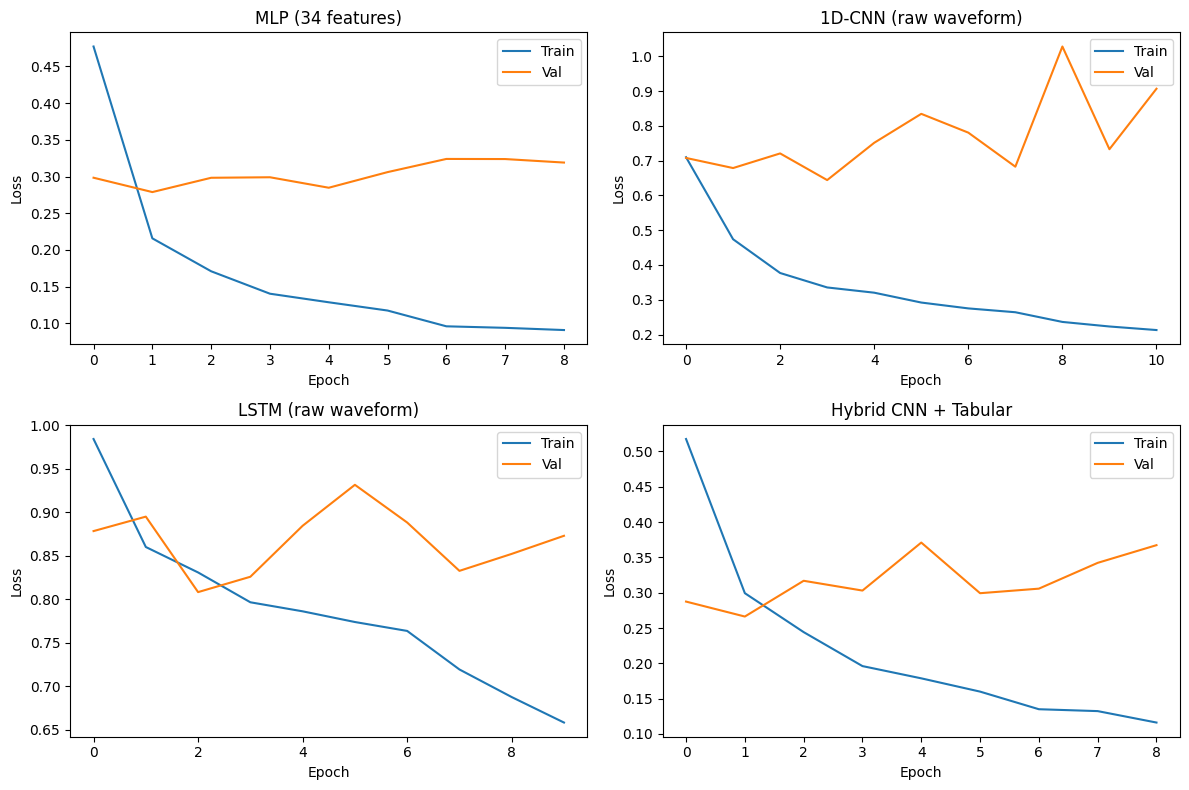


RESULTS SUMMARY (DS1 train / DS2 test, inter-patient split)
Model                            Macro F1
------------------------------------------
GB baseline (34 feat)              0.7020
GB no-amp (48 feat)                0.7340
MLP (34 features)                  0.6933
1D-CNN (raw waveform)              0.5720
LSTM (raw waveform)                0.5186
Hybrid CNN + Tabular               0.8032
------------------------------------------

All runs logged to MLflow. View with: mlflow ui --backend-store-uri file:///Users/dominicktan/projects/personal/ecg_monitor/mlruns


In [9]:
# --- Loss curves ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
configs = [
    ('MLP (34 features)', mlp_train_loss, mlp_val_loss),
    ('1D-CNN (raw waveform)', cnn_train_loss, cnn_val_loss),
    ('LSTM (raw waveform)', lstm_train_loss, lstm_val_loss),
    ('Hybrid CNN + Tabular', hybrid_train_loss, hybrid_val_loss),
]
for ax, (title, tl, vl) in zip(axes.flat, configs):
    ax.plot(tl, label='Train')
    ax.plot(vl, label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
plt.tight_layout()
plt.show()

# --- Summary table ---
print('\n' + '='*70)
print('RESULTS SUMMARY (DS1 train / DS2 test, inter-patient split)')
print('='*70)
print(f'{"Model":<30} {"Macro F1":>10}')
print('-'*42)
print(f'{"GB baseline (34 feat)":<30} {0.702:>10.4f}')
print(f'{"GB no-amp (48 feat)":<30} {0.734:>10.4f}')
print(f'{"MLP (34 features)":<30} {mlp_f1:>10.4f}')
print(f'{"1D-CNN (raw waveform)":<30} {cnn_f1:>10.4f}')
print(f'{"LSTM (raw waveform)":<30} {lstm_f1:>10.4f}')
print(f'{"Hybrid CNN + Tabular":<30} {hybrid_f1:>10.4f}')
print('-'*42)
print(f'\nAll runs logged to MLflow. View with: mlflow ui --backend-store-uri file://{MLFLOW_TRACKING_DIR}')

## 6. Per-Record Analysis: Hybrid CNN + Tabular

Detailed per-record breakdown on DS2 test set, with record 232 impact analysis.

In [10]:
import pandas as pd

# --- Get per-beat predictions from the hybrid model ---
df_results = df_test[['record', 'clinical_label']].copy()
df_results['pred'] = hybrid_preds

# --- Per-record metrics ---
records = sorted(df_results['record'].unique())
rows = []
for rec in records:
    mask = df_results['record'] == rec
    y_true = df_results.loc[mask, 'clinical_label']
    y_pred = df_results.loc[mask, 'pred']
    n_beats = len(y_true)

    n_true = (y_true == 'N').sum()
    s_true = (y_true == 'S').sum()
    v_true = (y_true == 'V').sum()
    sve_burden = 100 * s_true / n_beats if n_beats > 0 else 0

    present = sorted(y_true.unique())
    f1s = f1_score(y_true, y_pred, labels=present, average=None, zero_division=0)
    f1_dict = dict(zip(present, f1s))

    macro = f1_score(y_true, y_pred, labels=['N', 'S', 'V'], average='macro', zero_division=0)

    rows.append({
        'Record': rec,
        'Beats': n_beats,
        'N': n_true, 'S': s_true, 'V': v_true,
        'SVE%': f'{sve_burden:.1f}',
        'N F1': f'{f1_dict.get("N", 0):.3f}',
        'S F1': f'{f1_dict.get("S", 0):.3f}' if s_true > 0 else '\u2014',
        'V F1': f'{f1_dict.get("V", 0):.3f}' if v_true > 0 else '\u2014',
        'Macro F1': f'{macro:.3f}',
    })

df_per_record = pd.DataFrame(rows)
print('Per-Record Hybrid CNN Performance (DS2)')
print('=' * 90)
print(df_per_record.to_string(index=False))

print('\n\nRecords with S beats (sorted by S F1):')
print('-' * 70)
s_records = df_per_record[df_per_record['S'] > 0].copy()
s_records['_s_f1'] = s_records['S F1'].apply(lambda x: float(x) if x != '\u2014' else 0)
s_records = s_records.sort_values('_s_f1')
print(s_records[['Record', 'Beats', 'S', 'SVE%', 'S F1', 'Macro F1']].to_string(index=False))

Per-Record Hybrid CNN Performance (DS2)
Record  Beats    N    S   V SVE%  N F1  S F1  V F1 Macro F1
   100   2271 2237   33   1  1.5 0.996 0.653 1.000    0.883
   103   2081 2079    2   0  0.1 0.998 0.000     —    0.333
   105   2526 2485    0  41  0.0 0.949     — 0.309    0.419
   111   2122 2121    0   1  0.0 0.997     — 0.500    0.499
   113   1794 1788    6   0  0.3 1.000 0.727     —    0.576
   117   1534 1533    1   0  0.1 0.999 0.333     —    0.444
   121   1859 1857    1   1  0.1 0.995 0.182 0.154    0.443
   123   1516 1513    0   3  0.0 0.999     — 1.000    0.666
   200   2583 1729   29 825  1.1 0.961 0.171 0.980    0.704
   202   2132 2058   54  20  2.5 0.907 0.217 0.167    0.430
   210   2638 2416   22 200  0.8 0.986 0.392 0.922    0.766
   212   2742 2742    0   0  0.0 0.987     —     —    0.329
   213   3249 2640   28 581  0.9 0.958 0.051 0.778    0.596
   214   2252 1998    0 254  0.0 0.876     — 0.434    0.437
   219   2033 1961    7  65  0.3 0.982 0.000 0.962    0.648


In [11]:
# --- Overall metrics excluding record 232 ---
mask_no232 = df_results['record'] != '232'
y_true_no232 = df_results.loc[mask_no232, 'clinical_label']
y_pred_no232 = df_results.loc[mask_no232, 'pred']

print('='*70)
print('Hybrid CNN + Tabular \u2014 EXCLUDING Record 232')
print('='*70)
print(f'Beats: {len(y_true_no232)} (removed {(~mask_no232).sum()} from record 232)')
print(f'S beats remaining: {(y_true_no232 == "S").sum()} / {(df_results["clinical_label"] == "S").sum()}')
print()
print(classification_report(y_true_no232, y_pred_no232, digits=3))

macro_no232 = f1_score(y_true_no232, y_pred_no232, average='macro')
s_f1_no232 = f1_score(y_true_no232, y_pred_no232, labels=['S'], average=None)[0]
per_class_no232 = f1_score(y_true_no232, y_pred_no232, labels=classes, average=None)
acc_no232 = np.mean(np.array(y_pred_no232) == np.array(y_true_no232))

print(f'Macro F1 (excl. 232): {macro_no232:.4f}')
print(f'S F1 (excl. 232):     {s_f1_no232:.4f}')

# --- Log excl-232 metrics to the hybrid run ---
with mlflow.start_run(run_id=hybrid_run_id):
    mlflow.log_metrics({
        'accuracy_excl232': float(acc_no232),
        'macro_f1_excl232': macro_no232,
        **{f'f1_{c}_excl232': float(f) for c, f in zip(classes, per_class_no232)},
    })
    record_csv = '/tmp/per_record_hybrid.csv'
    df_per_record.to_csv(record_csv, index=False)
    mlflow.log_artifact(record_csv, 'reports')
print(f'\nExcl-232 metrics logged to MLflow run: {hybrid_run_id}')

# --- Impact of Record 232 ---
print('\n' + '='*70)
print('Impact of Record 232')
print('='*70)

s_f1_all = f1_score(
    df_results['clinical_label'], df_results['pred'], labels=['S'], average=None
)[0]
macro_all = f1_score(
    df_results['clinical_label'], df_results['pred'], average='macro'
)

print(f'{"":<25} {"S F1":>8} {"Macro F1":>10}')
print('-' * 45)
print(f'{"All DS2 records":<25} {s_f1_all:>8.4f} {macro_all:>10.4f}')
print(f'{"Excluding record 232":<25} {s_f1_no232:>8.4f} {macro_no232:>10.4f}')
print(f'{"Delta":<25} {s_f1_no232 - s_f1_all:>+8.4f} {macro_no232 - macro_all:>+10.4f}')

# --- Compare to GB baselines excluding 232 ---
print('\n' + '='*70)
print('Comparison to GB baselines (excluding record 232)')
print('='*70)
print(f'{"Model":<30} {"S F1":>8} {"Macro F1":>10}')
print('-' * 50)
print(f'{"GB (34 feat)":<30} {0.415:>8.4f} {0.771:>10.4f}')
print(f'{"GB hybrid (59 feat)":<30} {0.530:>8.4f} {0.809:>10.4f}')
print(f'{"Hybrid CNN + Tabular":<30} {s_f1_no232:>8.4f} {macro_no232:>10.4f}')

Hybrid CNN + Tabular — EXCLUDING Record 232
Beats: 47604 (removed 1622 from record 232)
S beats remaining: 446 / 1769

              precision    recall  f1-score   support

           N      0.992     0.950     0.971     43586
           S      0.170     0.632     0.268       446
           V      0.777     0.918     0.841      3572

    accuracy                          0.945     47604
   macro avg      0.647     0.833     0.694     47604
weighted avg      0.969     0.945     0.955     47604

Macro F1 (excl. 232): 0.6935
S F1 (excl. 232):     0.2682

Excl-232 metrics logged to MLflow run: dc71075bfdeb4c208ba853a8988aa096

Impact of Record 232
                              S F1   Macro F1
---------------------------------------------
All DS2 records             0.6009     0.8032
Excluding record 232        0.2682     0.6935
Delta                      -0.3327    -0.1097

Comparison to GB baselines (excluding record 232)
Model                              S F1   Macro F1
---------------

## 7. Multi-Run Stability Analysis: Hybrid CNN + Tabular

Run the hybrid model across 5 seeds to measure run-to-run variance
and get reliable mean performance estimates.

In [14]:
import pandas as pd

SEEDS = [0, 1, 2, 3, 4]
run_results = []

for seed in SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)

    with mlflow.start_run(run_name=f'Hybrid_CNN_seed{seed}'):
        mlflow.log_params({
            'model': 'Hybrid_CNN_Tabular',
            'input_type': 'waveform+tabular',
            'seq_len': wf_len,
            'n_features': len(FEATURE_COLS),
            'split': 'DS1_DS2_interpatient',
            'seed': seed,
            'batch_size': 256,
            'lr': 1e-3,
            'class_weighted': True,
        })

        model = HybridCNN(
            seq_len=wf_len, n_tabular=len(FEATURE_COLS), num_classes=len(classes)
        ).to(device)
        model.wf_len = wf_len

        print(f'\n{"="*60}')
        print(f'Seed {seed}')
        print(f'{"="*60}')
        train_model(model, train_loader_hyb, test_loader_hyb)
        macro_f1, preds = evaluate_model(model, test_loader_hyb, f'Hybrid CNN seed={seed}')

        torch.save(model.state_dict(), f'/tmp/hybrid_seed{seed}.pt')
        mlflow.log_artifact(f'/tmp/hybrid_seed{seed}.pt', 'model')

        # Collect per-class metrics
        per_class = f1_score(
            df_test['clinical_label'], preds, labels=classes, average=None
        )
        acc = np.mean(np.array(preds) == np.array(df_test['clinical_label']))

        run_results.append({
            'seed': seed,
            'accuracy': acc,
            'f1_N': per_class[0], 'f1_S': per_class[1], 'f1_V': per_class[2],
            'macro_f1': macro_f1,
        })

df_runs = pd.DataFrame(run_results)


Seed 0
Epoch   1: Train=0.5351 | Val=0.3150 | LR=1.0e-03 *
Epoch   2: Train=0.3057 | Val=0.2905 | LR=1.0e-03 *
Epoch   3: Train=0.2268 | Val=0.2852 | LR=1.0e-03 *
Epoch   4: Train=0.1891 | Val=0.2725 | LR=1.0e-03 *
Epoch   5: Train=0.1767 | Val=0.2824 | LR=1.0e-03
Epoch  10: Train=0.1151 | Val=0.2761 | LR=5.0e-04
Early stopping at epoch 11 (best val loss: 0.2725)

=== Hybrid CNN seed=0 ===
              precision    recall  f1-score   support

           N      0.978     0.957     0.968     43885
           S      0.398     0.600     0.479      1769
           V      0.883     0.891     0.887      3572

    accuracy                          0.940     49226
   macro avg      0.753     0.816     0.778     49226
weighted avg      0.950     0.940     0.944     49226

Macro F1: 0.7778

Seed 1
Epoch   1: Train=0.5185 | Val=0.2859 | LR=1.0e-03 *
Epoch   3: Train=0.2410 | Val=0.2769 | LR=1.0e-03 *
Epoch   5: Train=0.1809 | Val=0.2752 | LR=1.0e-03 *
Epoch  10: Train=0.1106 | Val=0.3604 | LR=5.

In [15]:
# --- Per-seed results ---
print('Per-seed results:')
print('-' * 65)
print(df_runs.to_string(index=False, float_format='{:.4f}'.format))

print(f'\nMean:  acc={df_runs["accuracy"].mean():.4f}  '
      f'N={df_runs["f1_N"].mean():.4f}  '
      f'S={df_runs["f1_S"].mean():.4f}  '
      f'V={df_runs["f1_V"].mean():.4f}  '
      f'macro={df_runs["macro_f1"].mean():.4f}')
print(f'Std:   acc={df_runs["accuracy"].std():.4f}  '
      f'N={df_runs["f1_N"].std():.4f}  '
      f'S={df_runs["f1_S"].std():.4f}  '
      f'V={df_runs["f1_V"].std():.4f}  '
      f'macro={df_runs["macro_f1"].std():.4f}')

# --- Comparison to GB baselines ---
print(f'\n{"="*65}')
print('Comparison to GB baselines (all DS2)')
print(f'{"="*65}')
print(f'{"Model":<35} {"Acc":>7} {"N F1":>7} {"S F1":>7} {"V F1":>7} {"Macro":>7}')
print('-' * 65)
print(f'{"GB (34 feat)":<35} {0.949:>7.4f} {0.972:>7.4f} {0.228:>7.4f} {0.907:>7.4f} {0.702:>7.4f}')
print(f'{"GB no-amp (48 feat)":<35} {0.955:>7.4f} {0.976:>7.4f} {0.309:>7.4f} {0.917:>7.4f} {0.734:>7.4f}')
m = df_runs
print(f'{"Hybrid CNN (mean)":<35} '
      f'{m["accuracy"].mean():>7.4f} '
      f'{m["f1_N"].mean():>7.4f} '
      f'{m["f1_S"].mean():>7.4f} '
      f'{m["f1_V"].mean():>7.4f} '
      f'{m["macro_f1"].mean():>7.4f}')
print(f'{"Hybrid CNN (std)":<35} '
      f'{m["accuracy"].std():>7.4f} '
      f'{m["f1_N"].std():>7.4f} '
      f'{m["f1_S"].std():>7.4f} '
      f'{m["f1_V"].std():>7.4f} '
      f'{m["macro_f1"].std():>7.4f}')

Per-seed results:
-----------------------------------------------------------------
 seed  accuracy   f1_N   f1_S   f1_V  macro_f1
    0    0.9397 0.9677 0.4788 0.8869    0.7778
    1    0.9146 0.9528 0.4472 0.8756    0.7586
    2    0.9353 0.9647 0.5435 0.8554    0.7879
    3    0.9085 0.9481 0.4745 0.8170    0.7466
    4    0.9352 0.9641 0.5903 0.8370    0.7972

Mean:  acc=0.9267  N=0.9595  S=0.5069  V=0.8544  macro=0.7736
Std:   acc=0.0141  N=0.0085  S=0.0585  V=0.0283  macro=0.0208

Comparison to GB baselines (all DS2)
Model                                   Acc    N F1    S F1    V F1   Macro
-----------------------------------------------------------------
GB (34 feat)                         0.9490  0.9720  0.2280  0.9070  0.7020
GB no-amp (48 feat)                  0.9550  0.9760  0.3090  0.9170  0.7340
Hybrid CNN (mean)                    0.9267  0.9595  0.5069  0.8544  0.7736
Hybrid CNN (std)                     0.0141  0.0085  0.0585  0.0283  0.0208


## Export Hybrid CNN Artifacts

Save the best Hybrid CNN model weights, scaler, and metadata for deployment.
This replaces the standalone `export_hybrid_cnn.py` script.

In [ ]:
import os, joblib

MODELS_DIR = 'models'
os.makedirs(MODELS_DIR, exist_ok=True)

# Find best seed from multi-run results
best_row = df_runs.loc[df_runs['macro_f1'].idxmax()]
best_seed = int(best_row['seed'])
print(f'Best seed: {best_seed} (macro F1 = {best_row["macro_f1"]:.3f})')

# Load best model weights
best_model = HybridCNN(seq_len=wf_len, n_tabular=len(FEATURE_COLS), num_classes=len(classes))
best_model.load_state_dict(torch.load(f'/tmp/hybrid_seed{best_seed}.pt',
                                       map_location='cpu', weights_only=True))
best_model.eval()

# Save artifacts
joblib.dump(scaler, f'{MODELS_DIR}/feature_scaler.joblib')
torch.save(best_model.state_dict(), f'{MODELS_DIR}/hybrid_cnn.pt')

metadata = {
    'wf_len': wf_len,
    'n_tabular': len(FEATURE_COLS),
    'num_classes': len(classes),
    'classes': classes,
    'feature_cols': FEATURE_COLS,
    'seed': best_seed,
}
joblib.dump(metadata, f'{MODELS_DIR}/hybrid_cnn_metadata.joblib')

print('\nArtifacts saved to models/')
for name in ['feature_scaler.joblib', 'hybrid_cnn.pt', 'hybrid_cnn_metadata.joblib']:
    size = os.path.getsize(f'{MODELS_DIR}/{name}')
    print(f'  {name:<35s} {size / 1024:.1f} KB')